c:\Users\gredy\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\tasks.py:548: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, m

📁 Found 30 images



0: 416x640 1 License_Plate, 9.8ms
Speed: 1.0ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)

0: 256x640 1 1, 1 6, 2 9s, 1 B, 1 J, 1 T, 6.0ms
Speed: 1.0ms preprocess, 6.0ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 1 License_Plate, 8.5ms
Speed: 2.0ms preprocess, 8.5ms inference, 2.6ms postprocess per image at shape (1, 3, 416, 640)

0: 256x640 1 3, 1 4, 1 8, 1 9, 1 B, 1 F, 1 U, 1 Z, 6.1ms
Speed: 1.0ms preprocess, 6.1ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 1 License_Plate, 9.2ms
Speed: 2.0ms preprocess, 9.2ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 224x640 1 7, 2 8s, 1 9, 2 Bs, 1 I, 8.9ms
Speed: 0.0ms preprocess, 8.

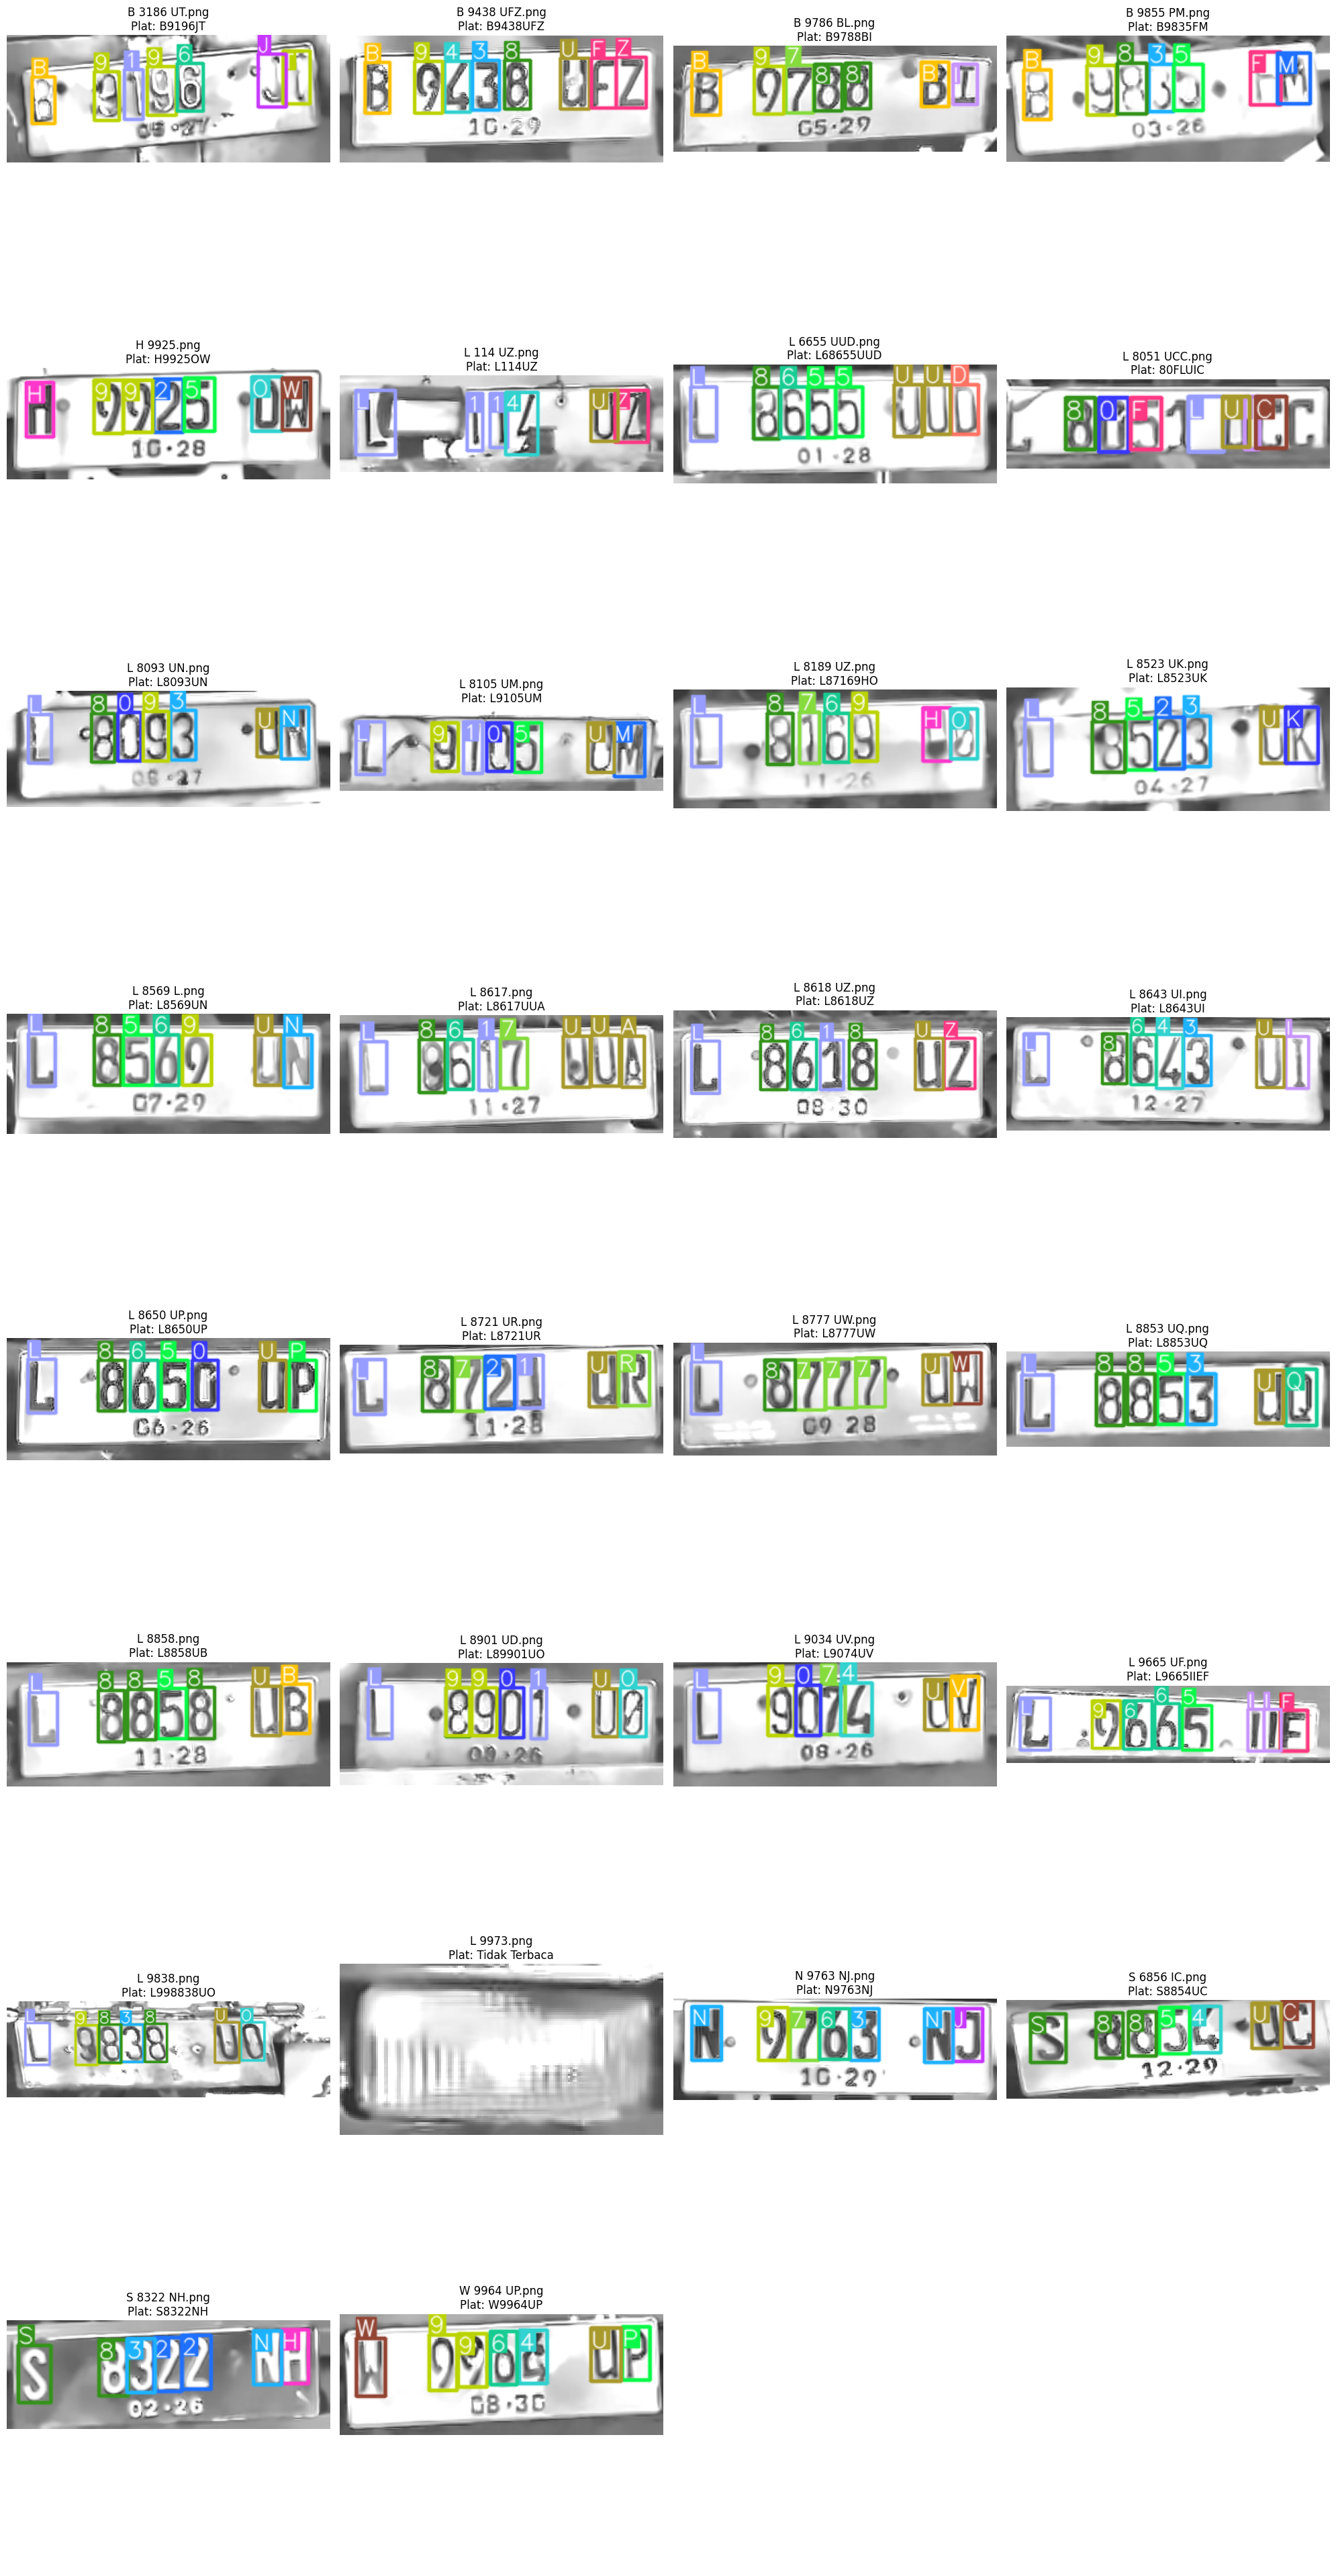

In [10]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from modules.preprocessing import Preprocessor

# Load models
plat_model = YOLO("models/plat.pt")
char_model = YOLO("models/char.pt")
preprocessor = Preprocessor()

# Path folder gambar
folder_path = r"D:\Work\PT TPS\ALPR Model Training\Dataset TPS"

# Dapatkan semua file gambar
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
image_paths = []

for extension in image_extensions:
    image_paths.extend(glob.glob(os.path.join(folder_path, extension)))

print(f"📁 Found {len(image_paths)} images")

# Setup subplot
cols = 4
rows = (len(image_paths) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
if rows == 1:
    axes = [axes] if cols == 1 else axes
else:
    axes = axes.flatten()

# Process each image
for i, image_path in enumerate(image_paths):
    if i < len(axes):
        # Load image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Plat detection
        plat_results = plat_model.predict(image_rgb, conf=0.1, iou=0.5)

        if plat_results[0].boxes:
            # Get first plate detection
            x1, y1, x2, y2 = plat_results[0].boxes.xyxy[0].cpu().numpy().astype(int)
            cropped_plate = image_rgb[y1:y2, x1:x2]

            # Preprocess plate image
            processed_plate = preprocessor.process(cropped_plate)

            # Convert grayscale to RGB for YOLO
            if len(processed_plate.shape) == 2:  # Grayscale
                processed_plate_rgb = cv2.cvtColor(processed_plate, cv2.COLOR_GRAY2RGB)
            else:
                processed_plate_rgb = processed_plate

            # Character detection on preprocessed plate
            char_results = char_model.predict(processed_plate_rgb, conf=0.2, iou=0.3)

            # Draw characters on preprocessed plate
            if char_results[0].boxes:
                char_image = char_results[0].plot(show_conf=False)
            else:
                # Convert back to RGB for display if no detections
                if len(processed_plate.shape) == 2:
                    char_image = cv2.cvtColor(processed_plate, cv2.COLOR_GRAY2RGB)
                else:
                    char_image = processed_plate

            # Get plate text
            plate_text = ""
            if char_results[0].boxes:
                boxes = char_results[0].boxes.xyxy.cpu().numpy()
                class_ids = char_results[0].boxes.cls.cpu().numpy().astype(int)
                sorted_indices = boxes[:, 0].argsort()
                plate_text = "".join(
                    [char_results[0].names[class_ids[i]] for i in sorted_indices]
                )

            # Display preprocessed plate with character detections
            axes[i].imshow(char_image)
            axes[i].set_title(
                f"{os.path.basename(image_path)}\nPlat: {plate_text if plate_text else 'Tidak Terbaca'}"
            )
        else:
            # No plate detected
            axes[i].imshow(image_rgb)
            axes[i].set_title(f"{os.path.basename(image_path)}\nNo plate detected")

        axes[i].axis("off")

# Hide unused axes
for i in range(len(image_paths), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

c:\Users\gredy\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\tasks.py:548: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, m

📁 Found 30 images



0: 416x640 1 License_Plate, 10.2ms
Speed: 2.0ms preprocess, 10.2ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 288x640 1 1, 1 6, 2 9s, 1 B, 1 J, 1 T, 10.1ms
Speed: 1.0ms preprocess, 10.1ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 1 License_Plate, 8.5ms


Original bbox: (705, 604, 1017, 727)
Expanded bbox: (703, 602, 1019, 729)


Speed: 2.0ms preprocess, 8.5ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 256x640 1 3, 1 4, 1 8, 1 9, 1 B, 1 F, 1 U, 1 Z, 6.5ms
Speed: 1.5ms preprocess, 6.5ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 1 License_Plate, 9.0ms
Speed: 2.0ms preprocess, 9.0ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 224x640 1 7, 2 8s, 1 9, 2 Bs, 1 I, 6.5ms
Speed: 1.0ms preprocess, 6.5ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.



...

Original bbox: (1202, 659, 1543, 741)
Expanded bbox: (1200, 657, 1545, 743)
Original bbox: (1212, 915, 1637, 1041)
Expanded bbox: (1210, 913, 1639, 1043)


0: 416x640 (no detections), 16.3ms
Speed: 2.0ms preprocess, 16.3ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 License_Plate, 17.8ms
Speed: 1.6ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 640)

0: 224x640 1 3, 1 6, 1 7, 1 9, 1 J, 2 Ns, 10.8ms
Speed: 0.5ms preprocess, 10.8ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 2 License_Plates, 16.6ms
Speed: 2.1ms preprocess, 16.6ms inference, 2.5ms postprocess per image at shape (1, 3, 416, 640)

0: 224x640 1 4, 1 5, 2 8s, 1 C, 1 S, 1 U, 6.5ms
Speed: 1.2ms preprocess, 6.5ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.


Original bbox: (580, 510, 886, 606)
Expanded bbox: (578, 508, 888, 608)
Original bbox: (511, 706, 812, 798)
Expanded bbox: (509, 704, 814, 800)



0: 416x640 1 License_Plate, 17.8ms
Speed: 2.0ms preprocess, 17.8ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 224x640 2 2s, 1 3, 1 8, 1 H, 1 N, 1 S, 5.6ms
Speed: 1.0ms preprocess, 5.6ms inference, 2.0ms postprocess per image at shape (1, 3, 224, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.

0: 416x640 1 License_Plate, 18.3ms
Speed: 2.0ms preprocess, 18.3ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)

0: 256x640 1 4, 1 6, 2 9s, 1 P, 1 U, 1 W, 7.4ms
Speed: 1.0ms preprocess, 7.4ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 640)
WARNING  'show_conf' is deprecated and will be removed in 'ultralytics 8.2' in the future. Please use 'conf' instead.


Original bbox: (752, 550, 1041, 647)
Expanded bbox: (750, 548, 1043, 649)
Original bbox: (795, 610, 1075, 715)
Expanded bbox: (793, 608, 1077, 717)


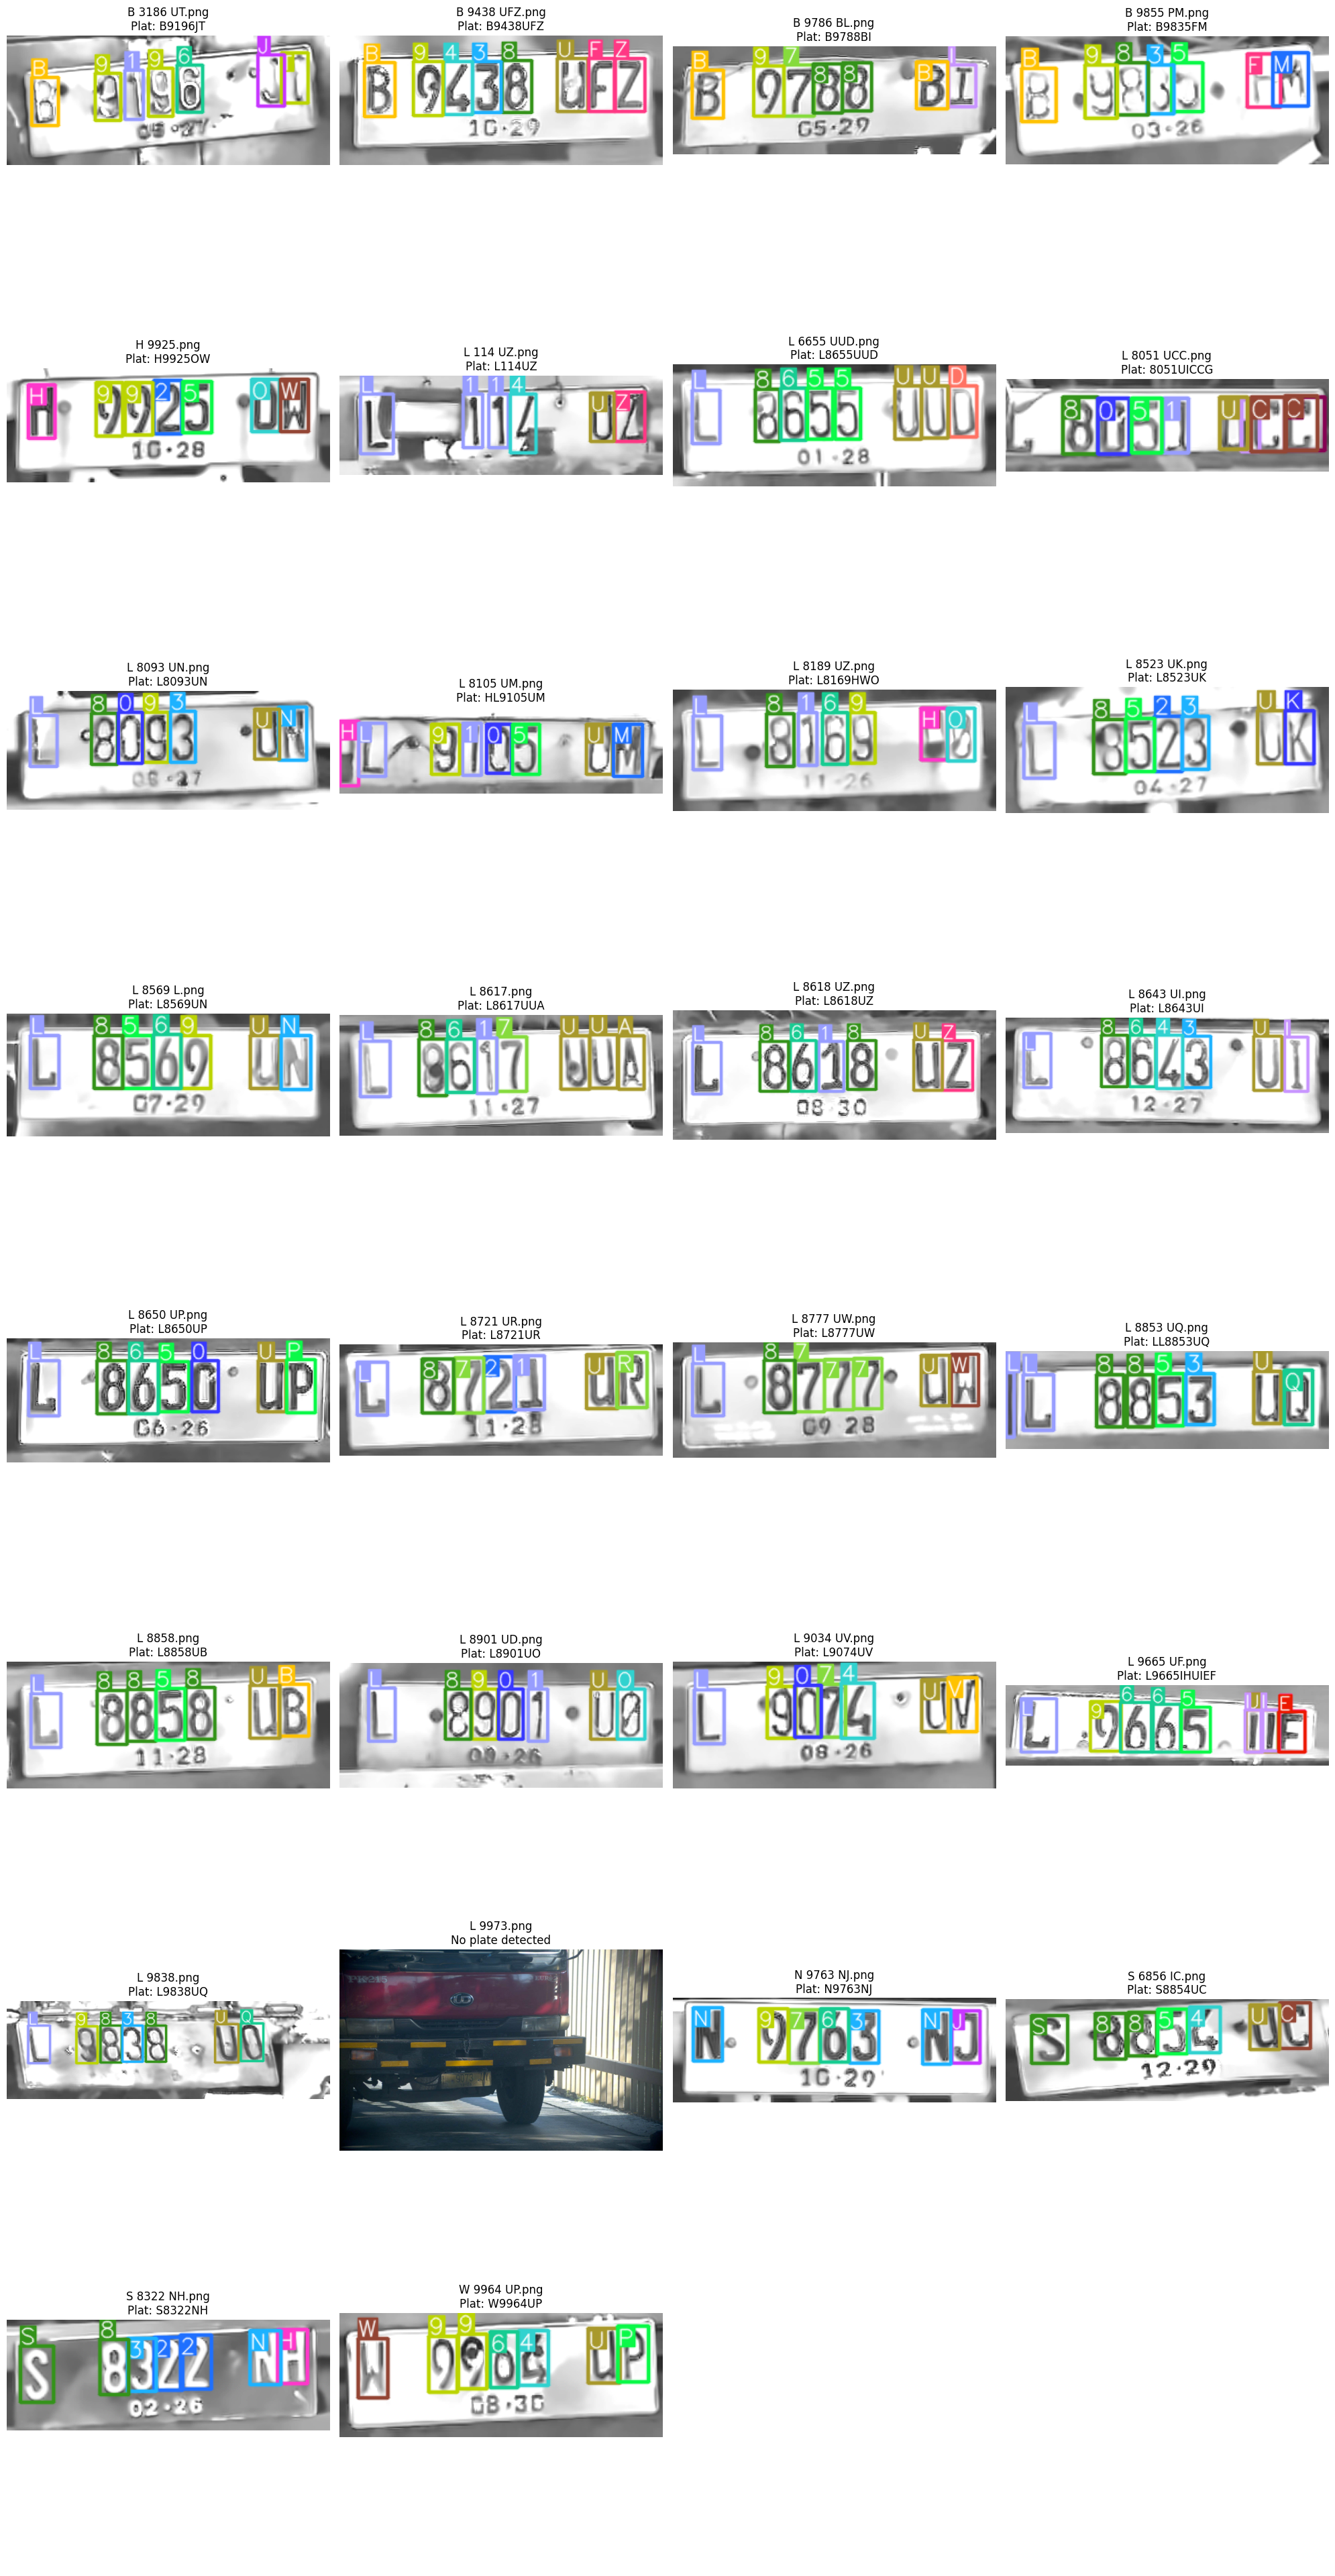

In [20]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from modules.preprocessing import Preprocessor

# Load models
plat_model = YOLO("models/plat.pt")
char_model = YOLO("models/charnew.pt")
preprocessor = Preprocessor()

# Path folder gambar
folder_path = r"D:\Work\PT TPS\ALPR Model Training\Dataset TPS"

# Dapatkan semua file gambar
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
image_paths = []

for extension in image_extensions:
    image_paths.extend(glob.glob(os.path.join(folder_path, extension)))

print(f"📁 Found {len(image_paths)} images")

# Setup subplot
cols = 4
rows = (len(image_paths) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
if rows == 1:
    axes = [axes] if cols == 1 else axes
else:
    axes = axes.flatten()

# Process each image
for i, image_path in enumerate(image_paths):
    if i < len(axes):
        # Load image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Plat detection
        plat_results = plat_model.predict(image_rgb)

        if plat_results[0].boxes:
            # Get first plate detection
            x1, y1, x2, y2 = plat_results[0].boxes.xyxy[0].cpu().numpy().astype(int)

            # ⭐ PERLUAS AREA CROPPING
            expand_pixels = 2  # Bisa disesuaikan
            h, w = image_rgb.shape[:2]

            # Expand bounding box dengan boundary check
            x1_exp = max(0, x1 - expand_pixels)
            y1_exp = max(0, y1 - expand_pixels)
            x2_exp = min(w, x2 + expand_pixels)
            y2_exp = min(h, y2 + expand_pixels)

            print(f"Original bbox: ({x1}, {y1}, {x2}, {y2})")
            print(f"Expanded bbox: ({x1_exp}, {y1_exp}, {x2_exp}, {y2_exp})")

            cropped_plate = image_rgb[y1_exp:y2_exp, x1_exp:x2_exp]

            # Preprocess plate image
            processed_plate = preprocessor.process(cropped_plate)

            # Convert grayscale to RGB for YOLO
            if len(processed_plate.shape) == 2:  # Grayscale
                processed_plate_rgb = cv2.cvtColor(processed_plate, cv2.COLOR_GRAY2RGB)
            else:
                processed_plate_rgb = processed_plate

            # Character detection on preprocessed plate
            char_results = char_model.predict(processed_plate_rgb, conf=0.1)

            # Draw characters on preprocessed plate
            if char_results[0].boxes:
                char_image = char_results[0].plot(show_conf=False)
            else:
                # Convert back to RGB for display if no detections
                if len(processed_plate.shape) == 2:
                    char_image = cv2.cvtColor(processed_plate, cv2.COLOR_GRAY2RGB)
                else:
                    char_image = processed_plate

            # Get plate text
            plate_text = ""
            if char_results[0].boxes:
                boxes = char_results[0].boxes.xyxy.cpu().numpy()
                class_ids = char_results[0].boxes.cls.cpu().numpy().astype(int)
                sorted_indices = boxes[:, 0].argsort()
                plate_text = "".join(
                    [char_results[0].names[class_ids[i]] for i in sorted_indices]
                )

            # Display preprocessed plate with character detections
            axes[i].imshow(char_image)
            axes[i].set_title(
                f"{os.path.basename(image_path)}\nPlat: {plate_text if plate_text else 'Tidak Terbaca'}"
            )
        else:
            # No plate detected
            axes[i].imshow(image_rgb)
            axes[i].set_title(f"{os.path.basename(image_path)}\nNo plate detected")

        axes[i].axis("off")

# Hide unused axes
for i in range(len(image_paths), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()